<a href="https://colab.research.google.com/github/RoseMaryBiju/Computer-Vision-Projects/blob/unit1/unit1_Medical_X_ray_Enhancement_%26_Feature_Extraction_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

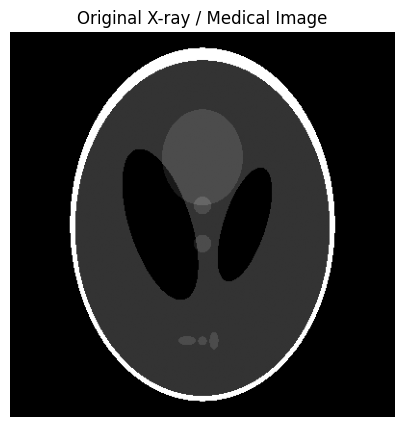

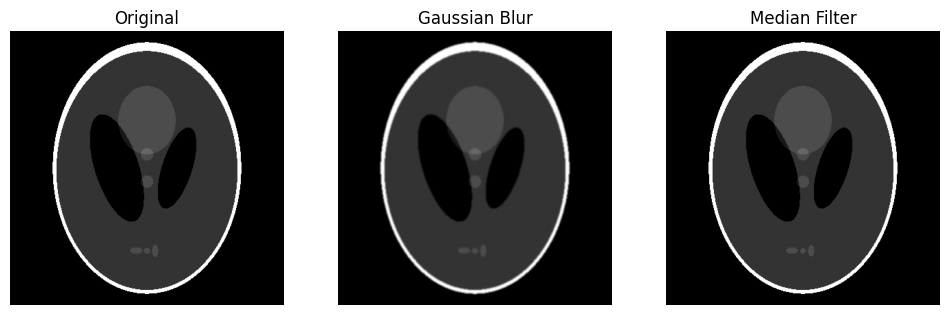

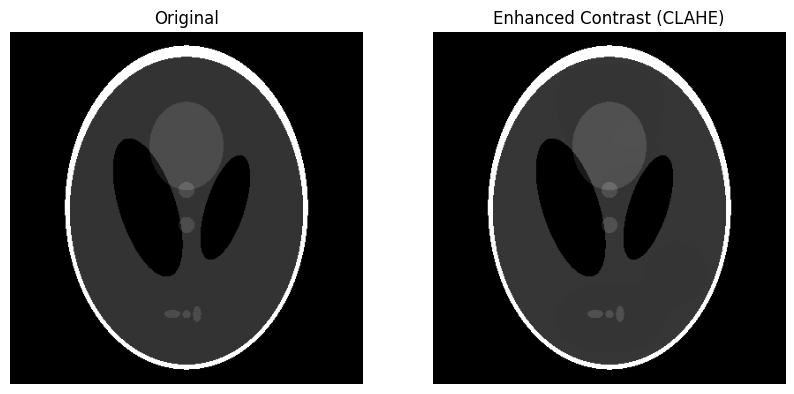

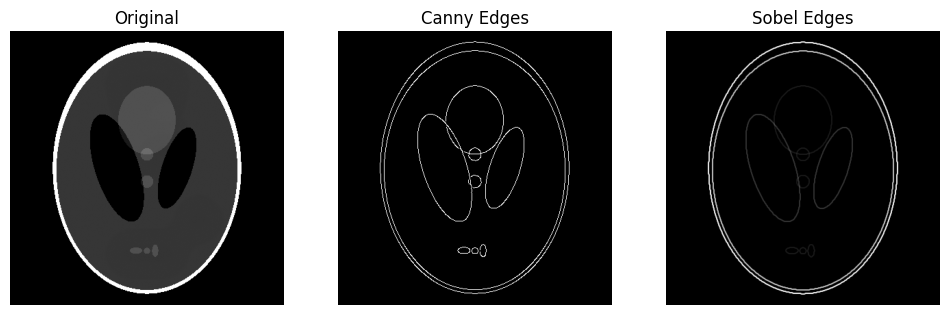

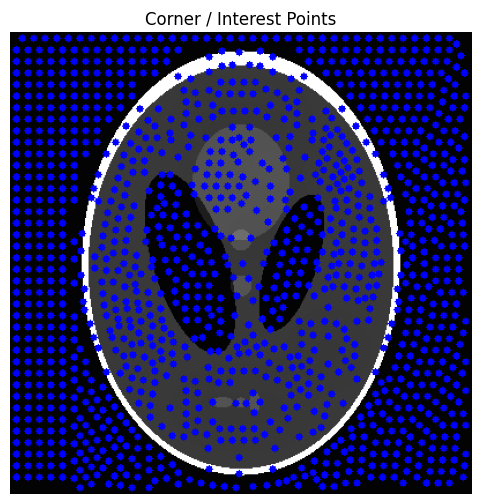

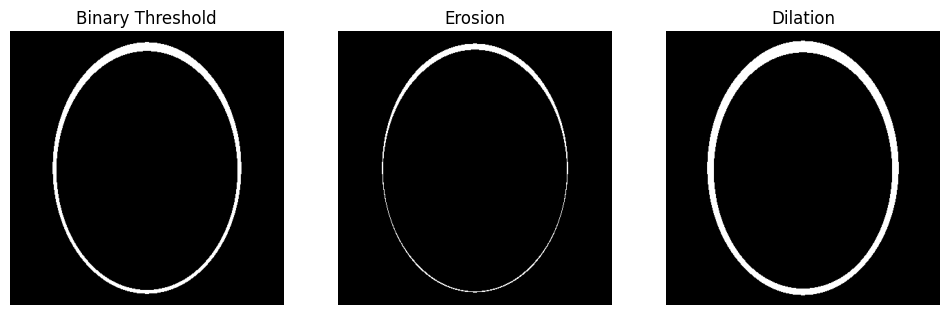

🔎 Texture Features for X-ray Region:
Contrast: 609.7994, Energy: 0.6174, Homogeneity: 0.9777


In [ ]:
# -------------------------------
# UNIT-1 APPLICATION: Medical X-ray Enhancement & Feature Extraction
# -------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, filters, feature, exposure, util, morphology
from skimage.feature import graycomatrix, graycoprops, corner_harris, corner_peaks
from scipy import ndimage as ndi

# 1️⃣ Load Sample X-ray Image (Built-in for demo)
# You can replace this with any X-ray image uploaded in Colab
from skimage import data
image = data.shepp_logan_phantom()  # synthetic medical phantom image
image = util.img_as_ubyte(image)
gray = image

plt.figure(figsize=(5,5))
plt.title("Original X-ray / Medical Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

# 2️⃣ Noise Reduction & Filtering
gaussian = cv2.GaussianBlur(gray, (5,5), 1)
median = cv2.medianBlur(gray, 5)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(gray, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Gaussian Blur"); plt.imshow(gaussian, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Median Filter"); plt.imshow(median, cmap='gray'); plt.axis('off')
plt.show()

# 3️⃣ Contrast Enhancement
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(gray)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.title("Original"); plt.imshow(gray, cmap='gray'); plt.axis('off')
plt.subplot(1,2,2); plt.title("Enhanced Contrast (CLAHE)"); plt.imshow(enhanced, cmap='gray'); plt.axis('off')
plt.show()

# 4️⃣ Edge Detection
edges_canny = cv2.Canny(enhanced, 50, 150)
edges_sobel = filters.sobel(enhanced)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(enhanced, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Canny Edges"); plt.imshow(edges_canny, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Sobel Edges"); plt.imshow(edges_sobel, cmap='gray'); plt.axis('off')
plt.show()

# 5️⃣ Corner Detection / Interest Points
corners = corner_peaks(corner_harris(enhanced), min_distance=5)
corner_img = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
for r, c in corners:
    cv2.circle(corner_img, (c,r), 3, (0,0,255), -1)

plt.figure(figsize=(6,6))
plt.title("Corner / Interest Points")
plt.imshow(corner_img)
plt.axis('off')
plt.show()

# 6️⃣ Morphological Operations (highlight features)
# Threshold image for bone-like regions
thresh_val = filters.threshold_otsu(enhanced)
binary = enhanced > thresh_val
eroded = morphology.erosion(binary, morphology.disk(2))
dilated = morphology.dilation(binary, morphology.disk(2))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Binary Threshold"); plt.imshow(binary, cmap='gray'); plt.axis('off')
plt.subplot(1,3,2); plt.title("Erosion"); plt.imshow(eroded, cmap='gray'); plt.axis('off')
plt.subplot(1,3,3); plt.title("Dilation"); plt.imshow(dilated, cmap='gray'); plt.axis('off')
plt.show()

# 7️⃣ Texture Analysis (GLCM Features)
glcm = graycomatrix(enhanced, distances=[1,2], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], symmetric=True, normed=True)
contrast = graycoprops(glcm, 'contrast').mean()
energy = graycoprops(glcm, 'energy').mean()
homogeneity = graycoprops(glcm, 'homogeneity').mean()

print("🔎 Texture Features for X-ray Region:")
print(f"Contrast: {contrast:.4f}, Energy: {energy:.4f}, Homogeneity: {homogeneity:.4f}")